FITS path: /Users/Igniz/Desktop/ICRAR/nGIST_dev_7.6.4/SKY_SPECTRUM_2023-01-18T07_13_15_0001.fits
Exists: True

=== HDU LIST ===
Filename: /Users/Igniz/Desktop/ICRAR/nGIST_dev_7.6.4/SKY_SPECTRUM_2023-01-18T07_13_15_0001.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU    2538   ()      
  1                1 BinTableHDU     19   14721R x 4C   [1D, 1D, 1D, 1J]   

=== PRIMARY HEADER (first 30 keys) ===
    SIMPLE : True
    BITPIX : 16
     NAXIS : 0
    EXTEND : True
   COMMENT :   FITS (Flexible Image Transport System) format is defined in 'Astronomy
  and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H
   COMMENT :   FITS (Flexible Image Transport System) format is defined in 'Astronomy
  and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H
      DATE : 2024-07-17T11:55:27
    ORIGIN : ESO-PARANAL
  TELESCOP : ESO-VLT-U4
  INSTRUME : MUSE
        RA : 187.14372
       DEC : 15.05677
   EQUINOX : 2000.0

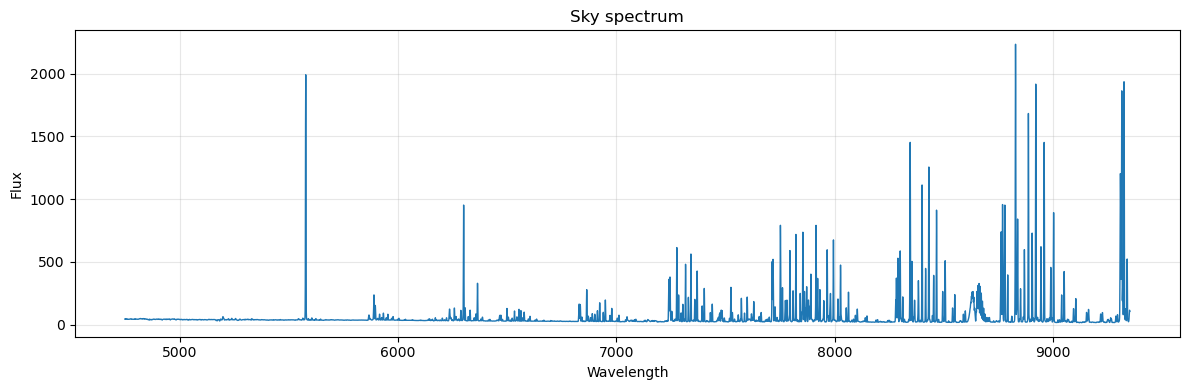

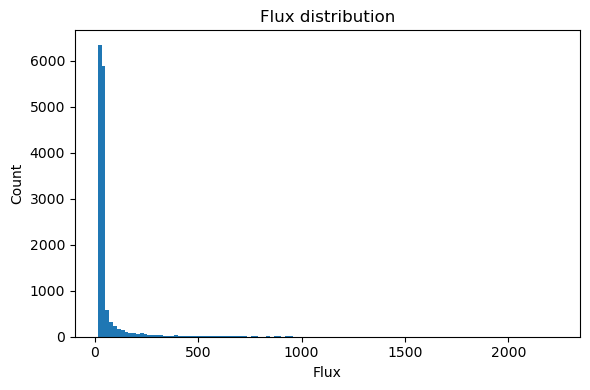

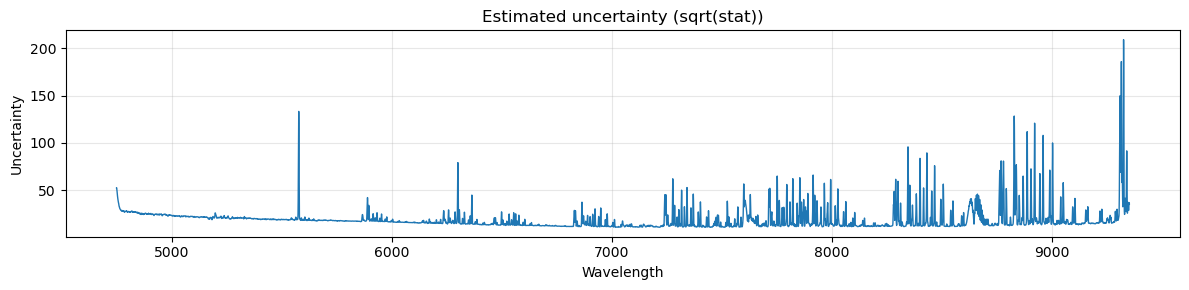


=== DQ SUMMARY ===
DQ=0: 14721 pixels


In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

fits_path = Path.cwd() / "SKY_SPECTRUM_2023-01-18T07_13_15_0001.fits"
print(f"FITS path: {fits_path}")
print(f"Exists: {fits_path.exists()}")

with fits.open(fits_path) as hdul:
    print("\n=== HDU LIST ===")
    hdul.info()

    print("\n=== PRIMARY HEADER (first 30 keys) ===")
    hdr = hdul[0].header
    for i, key in enumerate(hdr.keys()):
        if i >= 30:
            break
        print(f"{key:>10} : {hdr[key]}")

    # Choose first HDU with data; fallback to primary
    data_hdu_idx = None
    for i, hdu in enumerate(hdul):
        if getattr(hdu, "data", None) is not None:
            data_hdu_idx = i
            break
    if data_hdu_idx is None:
        data_hdu_idx = 0

    data = hdul[data_hdu_idx].data

print(f"\nUsing HDU index: {data_hdu_idx}")
print(f"Raw data type: {type(data)}")
print(f"Raw data dtype: {None if data is None else data.dtype}")
print(f"Raw data shape: {None if data is None else data.shape}")

if data is None:
    raise ValueError("No array data found in any HDU.")

# Handle FITS binary tables (structured arrays) vs plain numeric images
if hasattr(data, "names") and data.names is not None:
    colnames = [c.lower() for c in data.names]
    print("\n=== TABLE COLUMNS ===")
    print(data.names)

    # Prefer common column names
    wave_col = None
    flux_col = None
    stat_col = None
    dq_col = None

    for name in data.names:
        low = name.lower()
        if wave_col is None and low in ("lambda", "wave", "wavelength", "lam"):
            wave_col = name
        if flux_col is None and low in ("data", "flux", "spec", "spectrum"):
            flux_col = name
        if stat_col is None and low in ("stat", "var", "variance", "err", "error"):
            stat_col = name
        if dq_col is None and low in ("dq", "mask", "quality", "flag"):
            dq_col = name

    if wave_col is None and len(data.names) >= 1:
        wave_col = data.names[0]
    if flux_col is None and len(data.names) >= 2:
        flux_col = data.names[1]
    elif flux_col is None and len(data.names) >= 1:
        flux_col = data.names[0]

    wave = np.asarray(data[wave_col], dtype=float) if wave_col else np.arange(len(data), dtype=float)
    flux = np.asarray(data[flux_col], dtype=float)
    stat = np.asarray(data[stat_col], dtype=float) if stat_col else None
    dq = np.asarray(data[dq_col]) if dq_col else None

    finite = np.isfinite(wave) & np.isfinite(flux)
    wave_f = wave[finite]
    flux_f = flux[finite]

    print("\n=== SELECTED COLUMNS ===")
    print(f"Wavelength column: {wave_col}")
    print(f"Flux column: {flux_col}")
    print(f"Stat column: {stat_col}")
    print(f"DQ column: {dq_col}")

    print("\n=== FLUX STATS (finite values) ===")
    print(f"Total rows: {len(flux)}")
    print(f"Finite rows: {len(flux_f)}")
    if len(flux_f) > 0:
        print(f"Flux min / max: {flux_f.min():.6g} / {flux_f.max():.6g}")
        print(f"Flux mean / std: {flux_f.mean():.6g} / {flux_f.std():.6g}")

    plt.figure(figsize=(12, 4))
    plt.plot(wave_f, flux_f, lw=1)
    plt.title("Sky spectrum")
    plt.xlabel("Wavelength")
    plt.ylabel("Flux")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.hist(flux_f, bins=120)
    plt.title("Flux distribution")
    plt.xlabel("Flux")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    if stat is not None:
        stat_f = stat[finite]
        err_f = np.sqrt(np.clip(stat_f, 0, None))
        plt.figure(figsize=(12, 3))
        plt.plot(wave_f, err_f, lw=1)
        plt.title("Estimated uncertainty (sqrt(stat))")
        plt.xlabel("Wavelength")
        plt.ylabel("Uncertainty")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    if dq is not None:
        unique_dq, counts_dq = np.unique(dq, return_counts=True)
        print("\n=== DQ SUMMARY ===")
        for v, c in zip(unique_dq, counts_dq):
            print(f"DQ={v}: {c} pixels")

else:
    arr = np.asarray(data, dtype=float)
    finite_vals = arr[np.isfinite(arr)]

    print("\n=== DATA STATS ===")
    print(f"Total elements: {arr.size}")
    print(f"Finite elements: {finite_vals.size}")
    if finite_vals.size > 0:
        print(f"Min / Max: {finite_vals.min():.6g} / {finite_vals.max():.6g}")
        print(f"Mean / Std: {finite_vals.mean():.6g} / {finite_vals.std():.6g}")

    if arr.ndim == 1:
        x = np.arange(arr.shape[0])
        plt.figure(figsize=(12, 4))
        plt.plot(x, arr, lw=1)
        plt.title("1D data")
        plt.xlabel("Pixel index")
        plt.ylabel("Value")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    elif arr.ndim >= 2:
        image = arr[0] if arr.ndim > 2 else arr
        vmin, vmax = np.nanpercentile(image, [5, 95]) if np.isfinite(image).any() else (None, None)
        plt.figure(figsize=(7, 5))
        plt.imshow(image, origin="lower", aspect="auto", cmap="viridis", vmin=vmin, vmax=vmax)
        plt.colorbar(label="Value")
        plt.title(f"Quick-look image from HDU {data_hdu_idx}")
        plt.tight_layout()
        plt.show()